<a href="https://colab.research.google.com/github/Rikibeto67/Analisis-Plataforma-Educacion-Online/blob/main/prueba_fundamentos_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**FUNDAMENTOS DE CIENCIA DE DATOS**

Generación RTD-25-01-05-0019-2  
Prueba - Fundamentos de ciencias de datos  
**Richard Sepúlveda M.**

**Importaciones y Configuración Global**

In [ ]:
# ==============================================================================
# CONFIGURACIÓN DEL ENTORNO Y LIBRERÍAS
# ==============================================================================

# Manejo de datos y operaciones numéricas
import numpy as np
import pandas as pd
import scipy.stats as stats

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocesamiento y Transformación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE

# Modelos de Machine Learning (Clasificación y Regresión)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score

# Métricas de Evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Configuración del Sistema
import warnings
warnings.filterwarnings("ignore") # Ocultar warnings para un reporte más limpio
sns.set_style("whitegrid")        # Estilo visual de las gráficas

# Configuración de Pipeline y Herramientas de Feature Engineering en Spark
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

# --- IMPORTACIONES PARA LA PARTE 4 (SPARK) ---
from pyspark.ml.classification import RandomForestClassifier as SparkRF # Usamos un alias
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import SparkSession

# --- Función auxiliar para separadores ---
def separador(titulo=""):
    print("\n" + "="*80)
    if titulo:
        print(titulo)
        print("="*80)


**Parte 1 - Análisis Exploratorio y Visualización (3 Pts)**

Dimensiones del DataFrame: 500 filas, 19 columnas

Primeras 10 filas de DataFrame
   id_estudiante         nombre  edad     genero       pais  \
0              1   Estudiante_1    56       Otro  Argentina   
1              2   Estudiante_2    46   Femenino   Colombia   
2              3   Estudiante_3    32  Masculino   Colombia   
3              4   Estudiante_4    60       Otro     México   
4              5   Estudiante_5    25   Femenino   Colombia   
5              6   Estudiante_6    38       Otro       Perú   
6              7   Estudiante_7    56  Masculino       Perú   
7              8   Estudiante_8    36  Masculino      Chile   
8              9   Estudiante_9    40  Masculino       Perú   
9             10  Estudiante_10    28       Otro       Perú   

   horas_estudio_semanal  sesiones_totales  tareas_completadas  \
0                     16                10                  31   
1                     24                76                  28   
2                     19  

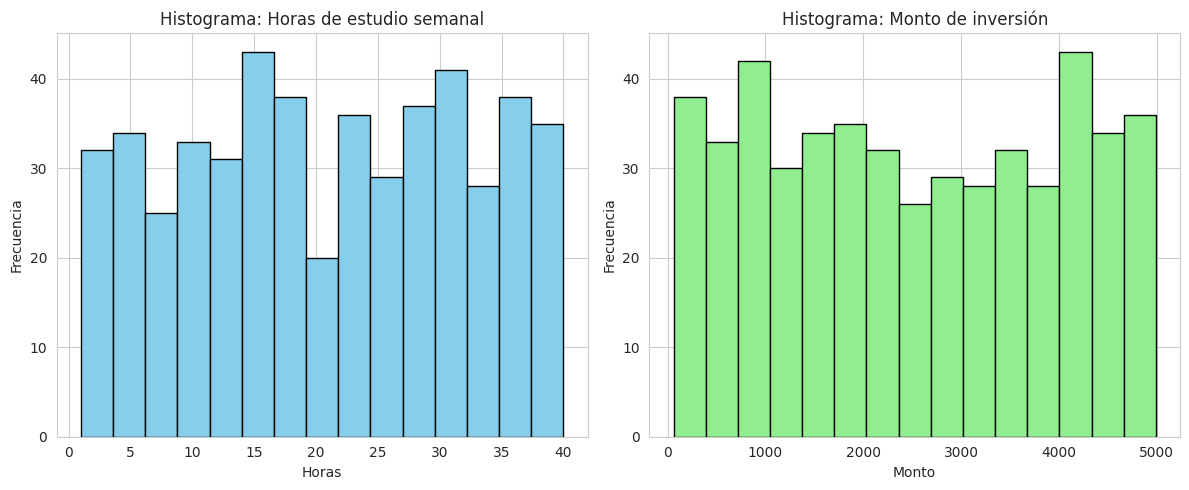


Visualización avanzada


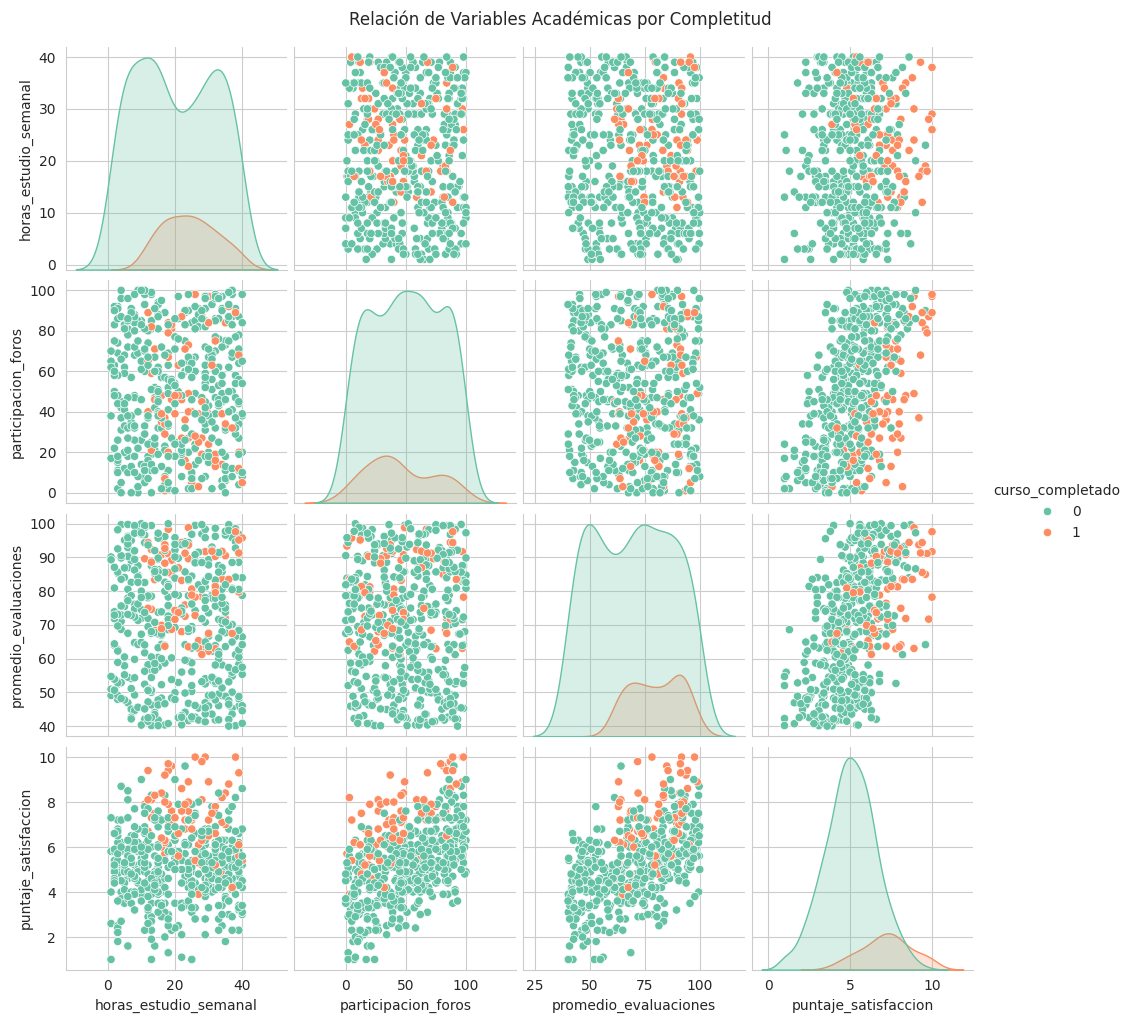

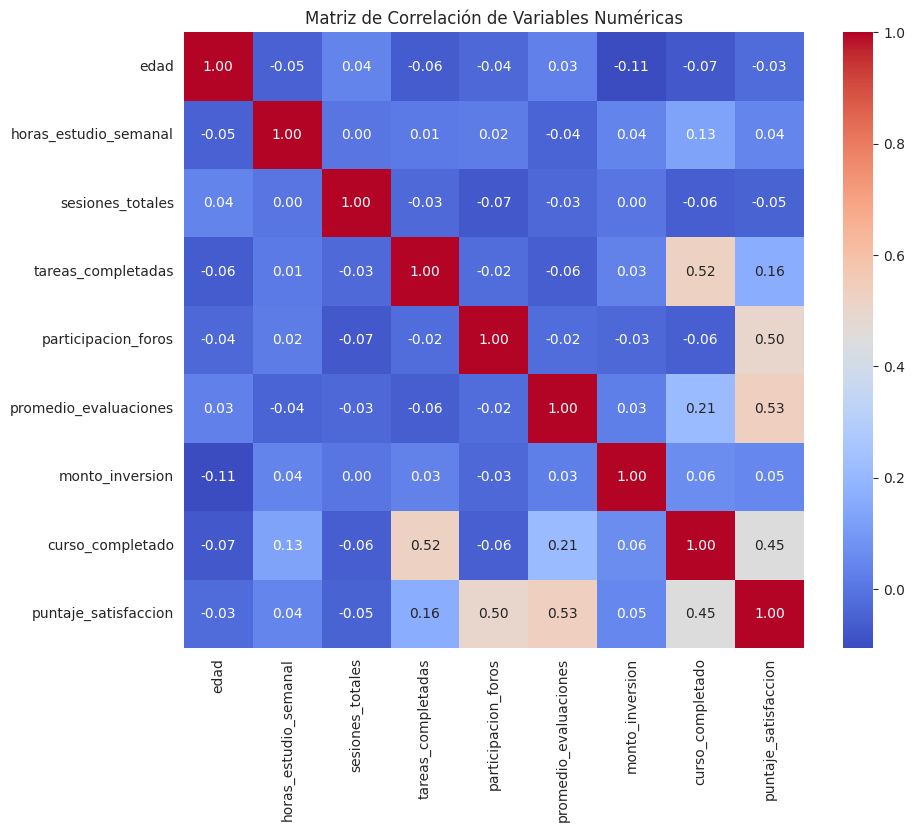

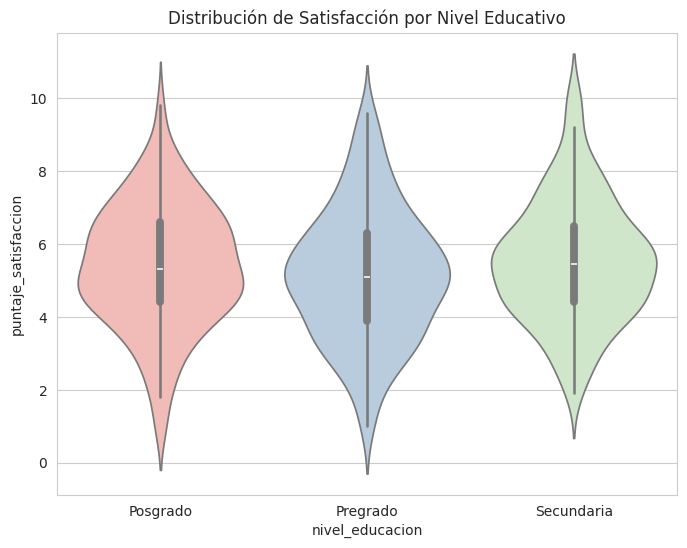

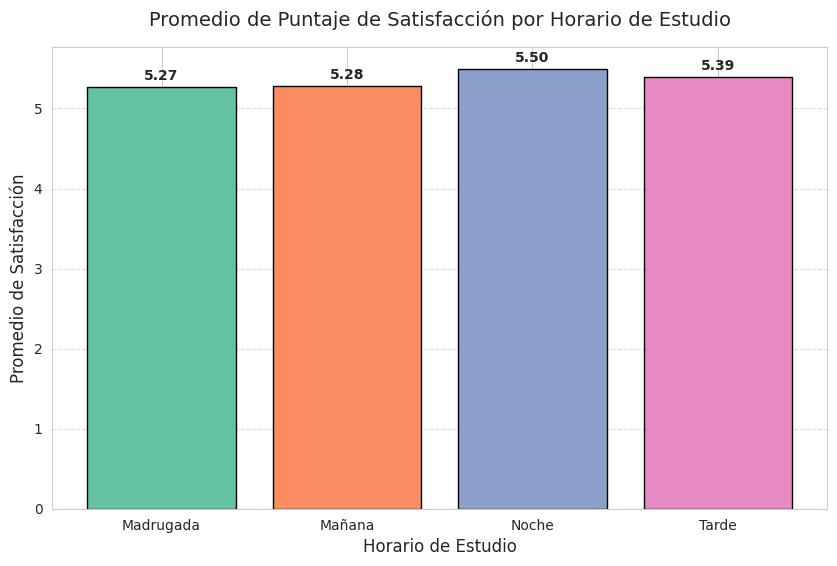

Parte 1 completada y archivo 'df_limpio_parte1.csv' guardado.


In [ ]:
# ==============================================================================
# PARTE 1: EXPLORACIÓN, LIMPIEZA Y VISUALIZACIÓN DE DATOS (3 Pts)
# ==============================================================================

# 1.1 Exploración Inicial y Carga de Datos
# ------------------------------------------------------------------------------

df = pd.read_csv("/content/estudiantes_edutech.csv")

# Exploración Inicial
print(f"Dimensiones del DataFrame: {df.shape[0]} filas, {df.shape[1]} columnas")

separador("Primeras 10 filas de DataFrame")
print(df.head(10))

# Limpieza: Eliminar constantes e IDs
constantes = [col for col in df.columns if df[col].nunique() <= 1]
df_limpio = df.drop(columns=constantes + ["id_estudiante", "nombre"])

separador("Estadísticas descriptivas")
print(df_limpio.describe())

separador("Información del DataFrame limpio")
print(df_limpio.info())

separador("Últimas 5 filas")
print(df_limpio.tail())

# --- Valores nulos ---
separador("Valores faltantes")
print(df_limpio.replace("", pd.NA).isnull().sum())
print("\nTotal de NaN en el DataFrame:", df.isna().sum().sum())

# --- Correlación ---
separador("Matriz de correlación (Pearson)")
num_cols = df_limpio.select_dtypes(include=[np.number])
corr_df = num_cols.corr(method="pearson")
print(corr_df)

# --- Outliers ---
def detectar_outliers(df, columna):
    Q1, Q3 = df[columna].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return df[(df[columna] < lim_inf) | (df[columna] > lim_sup)][[columna]]

separador("Outliers detectados")
print("Horas de estudio semanal:")
print(detectar_outliers(df_limpio, "horas_estudio_semanal"))
print("\nMonto de inversión:")
print(detectar_outliers(df_limpio, "monto_inversion"))

# Histogramas
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df_limpio["horas_estudio_semanal"], bins=15, color="skyblue", edgecolor="black")
plt.title("Histograma: Horas de estudio semanal")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.hist(df_limpio["monto_inversion"], bins=15, color="lightgreen", edgecolor="black")
plt.title("Histograma: Monto de inversión")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# 1.2 Visualización Avanzada con Seaborn

separador("Visualización avanzada")

# --- PAIRPLOT ---
vars_plot = ["horas_estudio_semanal", "participacion_foros", "promedio_evaluaciones", "puntaje_satisfaccion"]
pair = sns.pairplot(df_limpio, vars=vars_plot, hue="curso_completado", palette="Set2", diag_kind="kde")
pair.fig.suptitle("Relación de Variables Académicas por Completitud", y=1.02)
plt.show()

# --- HEATMAP ---
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio.select_dtypes(include=[np.number]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

# --- VIOLINPLOT ---
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_limpio, x="nivel_educacion", y="puntaje_satisfaccion", palette="Pastel1")
plt.title("Distribución de Satisfacción por Nivel Educativo")
plt.show()

# --- 1.3 Personalización con Matplotlib ---
# Calcular promedios
promedios = df_limpio.groupby("horario_estudio")["puntaje_satisfaccion"].mean().reset_index()

plt.figure(figsize=(10, 6))

colores = sns.color_palette("Set2", n_colors=len(promedios))

# Crear el gráfico de barras
bars = plt.bar(promedios["horario_estudio"],
               promedios["puntaje_satisfaccion"],
               color=colores,
               edgecolor="black")

# Personalización:
plt.title("Promedio de Puntaje de Satisfacción por Horario de Estudio", fontsize=14, pad=15)
plt.xlabel("Horario de Estudio", fontsize=12)
plt.ylabel("Promedio de Satisfacción", fontsize=12)

# Grid horizontal para facilitar lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Anotaciones con los valores exactos sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05,
             f'{yval:.2f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

# Guardar el gráfico
plt.savefig("satisfaccion_horario.png", dpi=300)

plt.show()

# Guardar archivo intermedio para la Parte 2
df_limpio.to_csv("/content/df_limpio_parte1.csv", index=False)
print("Parte 1 completada y archivo 'df_limpio_parte1.csv' guardado.")

**Parte 2 - Preparación de Datos y Feature Engineering (2 Pts)**

In [ ]:
# =========================================================
# PARTE 2: PREPARACIÓN DE DATOS Y FEATURE ENGINEERING
# =========================================================

# --- 2.0 CARGA ---
# Usamos el archivo generado en la Parte 1
df_limpio = pd.read_csv("df_limpio_parte1.csv")

# --- 2.1 TRANSFORMACIÓN DE VARIABLES ---
# Obtenemos el valor de tareas totales del df original

try:
    tareas_totales_valor = df["tareas_totales"].iloc[0]
except NameError:
    tareas_totales_valor = 50

df_limpio["tasa_completitud"] = (df_limpio["tareas_completadas"] / tareas_totales_valor) * 100
df_limpio["estudiante_activo"] = (df_limpio["sesiones_totales"] > 50).astype(int)

# --- 2.2 CODIFICACIÓN ---

# A. Codificación Ordinal (Mapeo manual para respetar jerarquía)
nivel_map = {"Secundaria": 0, "Universitaria": 1, "Posgrado": 2}
horario_map = {"Madrugada": 0, "Mañana": 1, "Tarde": 2, "Noche": 3}

df_limpio["nivel_educacion_enc"] = df_limpio["nivel_educacion"].map(nivel_map)
df_limpio["horario_estudio_enc"] = df_limpio["horario_estudio"].map(horario_map)

# B. Codificación Nominal (OneHotEncoder)
nominal_vars = ["genero", "pais", "dispositivo_principal", "experiencia_previa", "plataforma_origen"]
ohe = OneHotEncoder(sparse_output=False, drop="first")
encoded = ohe.fit_transform(df_limpio[nominal_vars])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_vars), index=df_limpio.index)

# C. Unión Final y Limpieza de columnas originales
cols_a_eliminar = nominal_vars + ["nivel_educacion", "horario_estudio"]
df_final = pd.concat([df_limpio.drop(columns=cols_a_eliminar), encoded_df], axis=1)

# --- 2.3 LIMPIEZA DE NULOS Y NORMALIZACIÓN ---
# Rellenamos cualquier NaN generado (vital para SMOTE y Modelos)
df_final = df_final.fillna(df_final.median())

# Identificamos columnas numéricas no binarias para escalar
binary_cols = [col for col in df_final.columns if set(df_final[col].dropna().unique()) <= {0,1}]
num_cols = [col for col in df_final.select_dtypes(include=[np.number]).columns if col not in binary_cols]

scaler = StandardScaler()
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

# --- 2.4 DIVISIÓN UNIFICADA (70/30) ---
# Separamos Features (X) y ambos Targets (y)
X = df_final.drop(columns=["curso_completado", "puntaje_satisfaccion"])
Y_targets = df_final[["curso_completado", "puntaje_satisfaccion"]]

# Hacemos el split una sola vez para mantener la integridad de las muestras
X_train, X_test, y_train_full, y_test_full = train_test_split(
    X,
    Y_targets,
    test_size=0.3,
    random_state=42,
    stratify=Y_targets["curso_completado"]
)

# Definimos los sets específicos para cada tarea
y_train_clf = y_train_full["curso_completado"]
y_test_clf = y_test_full["curso_completado"]
y_train_reg = y_train_full["puntaje_satisfaccion"]
y_test_reg = y_test_full["puntaje_satisfaccion"]

# --- 2.5 BALANCEO DE CLASES (SMOTE) ---
# Se aplica solo al set de entrenamiento de clasificación
if y_train_clf.value_counts(normalize=True).min() < 0.4:
    print("="*40)
    print("DESBALANCEO DETECTADO: Aplicando SMOTE")
    print("="*40)

    print("\nDistribución ORIGINAL (Antes de SMOTE):")
    print(y_train_clf.value_counts())

    smote = SMOTE(random_state=42)
    X_train_clf_bal, y_train_clf_bal = smote.fit_resample(X_train, y_train_clf)

    print("\nBALANCEO COMPLETADO")
    print("Distribución FINAL (Después de SMOTE):")
    print(y_train_clf_bal.value_counts()) # <--- Mostramos la versión balanceada
    print("="*40)

else:
    X_train_clf_bal, y_train_clf_bal = X_train, y_train_clf
    print("Clases balanceadas, no se requiere SMOTE.")

# --- 2.6 GUARDAR ---
# Guardamos el dataframe final procesado
df_final.to_csv("df_parte2_preparado.csv", index=False)
print("Parte 2 finalizada exitosamente. Archivo 'df_parte2_preparado.csv' guardado.")


DESBALANCEO DETECTADO: Aplicando SMOTE

Distribución ORIGINAL (Antes de SMOTE):
curso_completado
0    299
1     51
Name: count, dtype: int64

BALANCEO COMPLETADO
Distribución FINAL (Después de SMOTE):
curso_completado
0    299
1    299
Name: count, dtype: int64
Parte 2 finalizada exitosamente. Archivo 'df_parte2_preparado.csv' guardado.


**Parte 3 - Modelado y Evaluación (3 Pts)**

--- Optimizando Modelos de Clasificación ---
Mejores parámetros para RandomForest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Mejores parámetros para LogisticRegression: {'C': 1, 'penalty': 'l2'}

--- Reporte: RandomForest ---
Accuracy: 0.9867
ROC-AUC: 1.0000
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       128
           1       1.00      0.91      0.95        22

    accuracy                           0.99       150
   macro avg       0.99      0.95      0.97       150
weighted avg       0.99      0.99      0.99       150



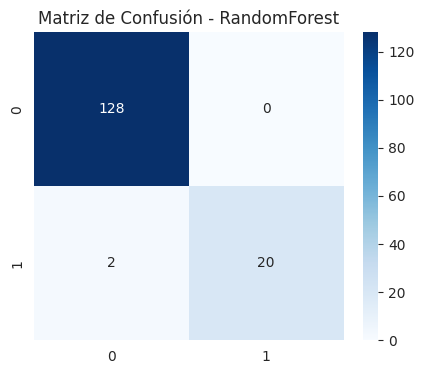


--- Reporte: LogisticRegression ---
Accuracy: 0.8933
ROC-AUC: 0.9435
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       128
           1       0.59      0.86      0.70        22

    accuracy                           0.89       150
   macro avg       0.78      0.88      0.82       150
weighted avg       0.92      0.89      0.90       150



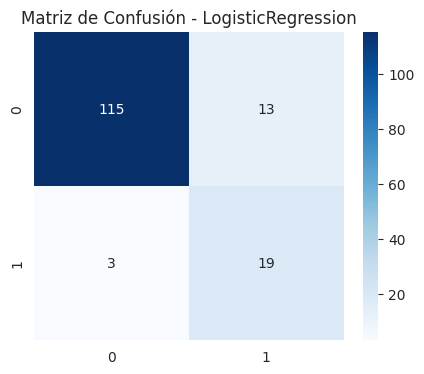


=== Comparación de Modelos ===
               Modelo  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0        RandomForest  0.986667    1.00000  0.909091  0.952381  1.000000
1  LogisticRegression  0.893333    0.59375  0.863636  0.703704  0.943537

--- Optimizando Modelos de Regresión ---
Mejores parámetros para RandomForestRegressor: {'max_depth': 20, 'n_estimators': 200}
Mejores parámetros para Ridge: {'alpha': 10.0}

--- Métricas Finales Regresión (RandomForestRegressor) ---
R² Score: 0.5946
MAE: 0.5183
RMSE: 0.6343


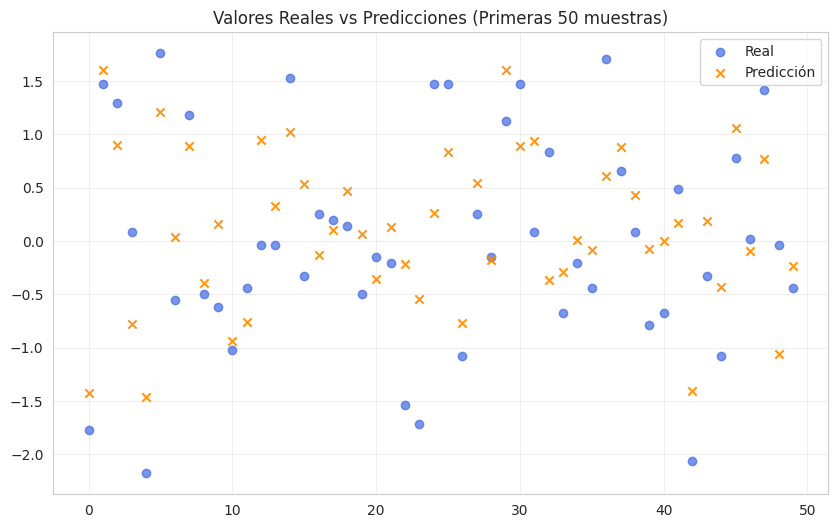

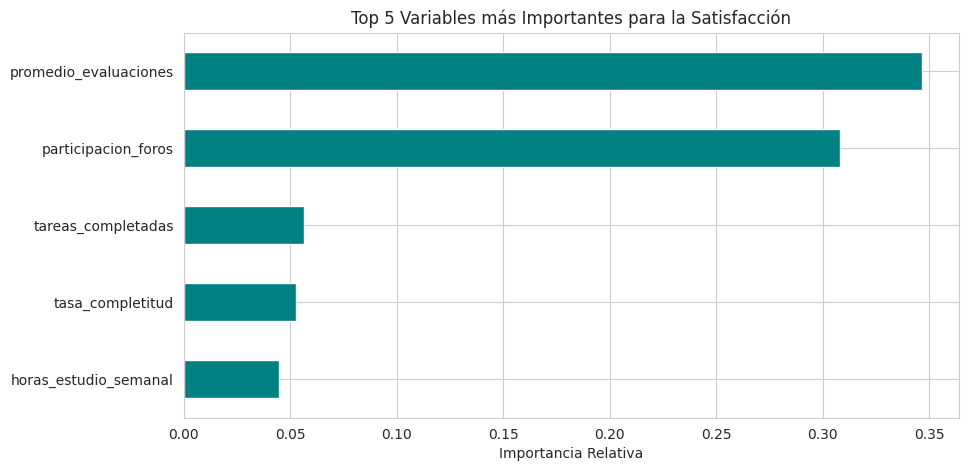


Parte 3 completada. Todos los modelos han sido entrenados y evaluados.


In [ ]:
# ==============================================================================
# 3.1 MODELO DE CLASIFICACIÓN: Predicción de Completitud del Curso
# ==============================================================================

print("--- Optimizando Modelos de Clasificación ---")

# 1. Configuración de Modelos e Hiperparámetros
models_clf = {
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }),
    'LogisticRegression': (LogisticRegression(max_iter=1000, solver='liblinear'), {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2']
    })
}

best_models_clf = {}

for name, (model, params) in models_clf.items():
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_clf_bal, y_train_clf_bal)
    best_models_clf[name] = grid.best_estimator_
    print(f"Mejores parámetros para {name}: {grid.best_params_}")

# 2. Evaluación y Comparación
for name, model in best_models_clf.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n--- Reporte: {name} ---")
    print(f"Accuracy: {accuracy_score(y_test_clf, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_prob):.4f}")
    print(classification_report(y_test_clf, y_pred))

    # Matriz de Confusión
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test_clf, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()

# Crear tabla comparativa de métricas
results = []

for name, model in best_models_clf.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test_clf, y_pred),
        "Precision": precision_score(y_test_clf, y_pred),
        "Recall": recall_score(y_test_clf, y_pred),
        "F1-Score": f1_score(y_test_clf, y_pred),
        "ROC-AUC": roc_auc_score(y_test_clf, y_prob)
    })

df_results = pd.DataFrame(results)
print("\n=== Comparación de Modelos ===")
print(df_results)


# ==============================================================================
# 3.2 MODELO DE REGRESIÓN: Estimación de Puntaje de Satisfacción
# ==============================================================================
print("\n--- Optimizando Modelos de Regresión ---")

# 1. Configuración de Modelos e Hiperparámetros
models_reg = {
    'RandomForestRegressor': (RandomForestRegressor(random_state=42), {
        'n_estimators': [100, 200],
        'max_depth': [10, 20]
    }),
    'Ridge': (Ridge(), {
        'alpha': [0.1, 1.0, 10.0, 100.0]
    })
}

best_models_reg = {}

for name, (model, params) in models_reg.items():
    grid = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train_reg)
    best_models_reg[name] = grid.best_estimator_
    print(f"Mejores parámetros para {name}: {grid.best_params_}")

# 2. Evaluación de Regresión (Usando el mejor modelo encontrado)
best_reg = best_models_reg['RandomForestRegressor'] # Usualmente es el más preciso
y_pred_reg = best_reg.predict(X_test)

print(f"\n--- Métricas Finales Regresión ({best_reg.__class__.__name__}) ---")
print(f"R² Score: {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")

# 3. Gráfico de Dispersión: Real vs Predicción (con dos colores)
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test_reg[:50])), y_test_reg[:50], color='royalblue', label='Real', alpha=0.7)
plt.scatter(range(len(y_pred_reg[:50])), y_pred_reg[:50], color='darkorange', marker='x', label='Predicción', alpha=0.9)
plt.title("Valores Reales vs Predicciones (Primeras 50 muestras)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Identificación de las 5 variables más importantes
importancias = pd.Series(best_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importancias.head(5).plot(kind='barh', color='teal').invert_yaxis()
plt.title("Top 5 Variables más Importantes para la Satisfacción")
plt.xlabel("Importancia Relativa")
plt.show()

print("\nParte 3 completada. Todos los modelos han sido entrenados y evaluados.")

**Parte 4: Procesamiento con Apache Spark MLlib (1.5 puntos)**

In [ ]:
# ==============================================================================
# 4.1 PREPARACIÓN EN SPARK
# ==============================================================================

# 1. Iniciar Sesión de Spark
spark = SparkSession.builder.appName("ProyectoEdutechSpark").getOrCreate()

# 2. Carga del dataset (Enlace con Parte 1)

try:
    df_spark = spark.read.csv("/content/df_limpio_parte1.csv", header=True, inferSchema=True)
    print("Datos cargados exitosamente en Spark desde la Parte 1.")
except:
    print("No se encontró el archivo. Asegúrate de haber ejecutado la Parte 1.")

# 3. Preparación de la etiqueta (Label)
# Renombramos 'curso_completado' a 'label' como pide la rúbrica
df_spark = df_spark.withColumnRenamed("curso_completado", "label")

# 4. Definición de columnas para el Pipeline
categorical_cols = ["genero", "nivel_educacion", "horario_estudio", "dispositivo_principal"]
numeric_cols = ["horas_estudio_semanal", "participacion_foros", "promedio_evaluaciones"]

# 5. Configuración de Transformadores
indexers = [StringIndexer(inputCol=col, outputCol=col+"_index", handleInvalid="keep")
            for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=[col+"_index" for col in categorical_cols] + numeric_cols,
    outputCol="features"
)

# 6. Construcción del Pipeline y Transformación
pipeline = Pipeline(stages=indexers + [assembler])
df_spark_final = pipeline.fit(df_spark).transform(df_spark)

# 7. División Train/Test (70/30)
train_df, test_df = df_spark_final.randomSplit([0.7, 0.3], seed=42)

# ==============================================================================
# 4.2 MODELO Y EVALUACIÓN EN SPARK
# ==============================================================================
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# 1. Entrenamiento: Usamos el alias SparkRF para evitar conflictos con Sklearn
rf = SparkRF(featuresCol="features", labelCol="label", numTrees=100, seed=42)
rf_model = rf.fit(train_df)

# 2. Generación de Predicciones
predictions = rf_model.transform(test_df)

# 3. Evaluación con Evaluadores de Spark
# areaUnderROC para evaluación binaria
binary_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Accuracy y F1 para evaluación multiclase
multi_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

roc_auc = binary_eval.evaluate(predictions)
accuracy = multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"})
f1_score_spark = multi_eval.evaluate(predictions, {multi_eval.metricName: "f1"})

# 4. Resultados Finales en Pantalla
print("\n" + "="*40)
print("MÉTRICAS DEL MODELO SPARK MLlib")
print("="*40)
print(f"ROC AUC:  {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1_score_spark:.4f}")
print("="*40)

# 5. Tabla requerida por rúbrica: label, prediction, probability
# 'probability' es un vector: [probabilidad de 0, probabilidad de 1]
predictions.select("label", "prediction", "probability").show(10, truncate=False)

Datos cargados exitosamente en Spark desde la Parte 1.

MÉTRICAS DEL MODELO SPARK MLlib
ROC AUC:  0.7831
Accuracy: 0.8492
F1 Score: 0.7800
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.8069814115054871,0.19301858849451295]|
|0    |0.0       |[0.7153500444267314,0.2846499555732686] |
|0    |0.0       |[0.680515640408029,0.3194843595919709]  |
|0    |0.0       |[0.9337525476639523,0.06624745233604769]|
|0    |0.0       |[0.7659002048951379,0.23409979510486206]|
|0    |0.0       |[0.9729322122258545,0.02706778777414554]|
|0    |0.0       |[0.961758510354856,0.03824148964514388] |
|0    |0.0       |[0.9539924038575698,0.0460075961424301] |
|0    |0.0       |[0.7792100341376612,0.22078996586233882]|
|0    |0.0       |[0.6477676875855822,0.3522323124144178] |
+-----+----------+----------------------------------------+
only showing top 10 r

**Parte 5: Inferencia Estadística (0.5 puntos)**

--- Análisis Descriptivo e Intervalo de Confianza ---
Media muestral de satisfacción: 5.36
Intervalo de Confianza al 95%: (5.21, 5.51)
--------------------------------------------------
--- Prueba de Hipótesis ---
H₀: No hay diferencia significativa en el puntaje de satisfacción entre grupos.
H₁: El puntaje de satisfacción entre quienes completan y no completan el curso es diferente.

Estadístico t: 11.4923
Valor-p: 0.0000

Resultado: p-val (0.0000) < alpha (0.05).
Conclusión: Se RECHAZA H₀. Hay diferencia significativa en el puntaje de satisfacción.
--------------------------------------------------


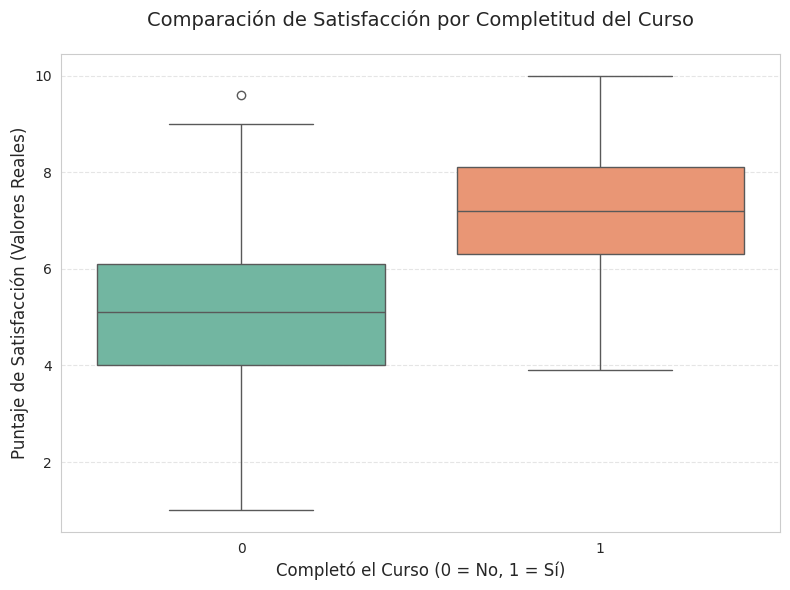


 ¡Examen completado de principio a fin!


In [ ]:
# ==============================================================================
# PARTE 5: INFERENCIA ESTADÍSTICA (0.5 PUNTOS)
# ==============================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- 5.0 CARGA DIRECTA DEL PASO 1 (DATOS SIN ESCALAR) ---
# Usamos el CSV de la Parte 1 para que las medias y gráficos sean legibles (escala real)
df_stats = pd.read_csv("/content/df_limpio_parte1.csv")


# ==============================================================================
# 5.1 INTERVALO DE CONFIANZA AL 95%
# ==============================================================================
media_sat = df_stats["puntaje_satisfaccion"].mean()
desv_sat = df_stats["puntaje_satisfaccion"].std()
n_obs = len(df_stats)

# Valor crítico para 95% de confianza (z = 1.96)
error_margen = 1.96 * (desv_sat / np.sqrt(n_obs))
ic_inferior, ic_superior = media_sat - error_margen, media_sat + error_margen

print("--- Análisis Descriptivo e Intervalo de Confianza ---")
print(f"Media muestral de satisfacción: {media_sat:.2f}")
print(f"Intervalo de Confianza al 95%: ({ic_inferior:.2f}, {ic_superior:.2f})")
print("-" * 50)


# ==============================================================================
# 5.2 PRUEBA DE HIPÓTESIS (t-test de Welch)
# ==============================================================================
print("--- Prueba de Hipótesis ---")
print("H₀: No hay diferencia significativa en el puntaje de satisfacción entre grupos.")
print("H₁: El puntaje de satisfacción entre quienes completan y no completan el curso es diferente.\n")

# Separar grupos
grupo_completado = df_stats[df_stats["curso_completado"] == 1]["puntaje_satisfaccion"]
grupo_no_completado = df_stats[df_stats["curso_completado"] == 0]["puntaje_satisfaccion"]

# t-test (equal_var=False asume varianzas distintas, lo cual es más robusto)
t_stat, p_val = stats.ttest_ind(grupo_completado, grupo_no_completado, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor-p: {p_val:.4f}")

# Conclusión
alpha = 0.05
if p_val < alpha:
    print(f"\nResultado: p-val ({p_val:.4f}) < alpha ({alpha}).")
    print("Conclusión: Se RECHAZA H₀. Hay diferencia significativa en el puntaje de satisfacción.")
else:
    print(f"\nResultado: p-val ({p_val:.4f}) >= alpha ({alpha}).")
    print("Conclusión: NO se rechaza H₀. No hay evidencia estadística de diferencia.")
print("-" * 50)


# ==============================================================================
# 5.3 VISUALIZACIÓN DE RESULTADOS (Boxplot en escala real)
# ==============================================================================
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_stats,
    x="curso_completado",
    y="puntaje_satisfaccion",
    palette="Set2",
    hue="curso_completado",
    legend=False
)

plt.title("Comparación de Satisfacción por Completitud del Curso", fontsize=14, pad=20)
plt.xlabel("Completó el Curso (0 = No, 1 = Sí)", fontsize=12)
plt.ylabel("Puntaje de Satisfacción (Valores Reales)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n ¡Examen completado de principio a fin!")